# Executive Summary

This project analyzes the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data.

The analysis includes:
- Data Cleaning and Preprocessing
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Sentiment Analysis
- Trader Segmentation
- Profitability Analysis
- Business Insights and Strategy Recommendations

The objective is to understand how market sentiment influences trading behavior and profitability, helping identify patterns that can support better trading decisions.

## Project Objective

This project analyzes the relationship between Bitcoin market sentiment (Fear vs Greed) and trader performance on Hyperliquid. The analysis focuses on trading behavior, profitability, leverage usage, and actionable trading strategies based on market sentiment.


## 1. Import Libraries

In [ ]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Chart Style
plt.style.use('ggplot')

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load Datase

In [42]:
# ==========================================================
# Upload Dataset Files
# ==========================================================

from google.colab import files

uploaded = files.upload()

Saving historical_data.csv to historical_data (1).csv
Saving fear_greed_index.csv to fear_greed_index (1).csv


In [ ]:
# ==========================================================
# Load CSV Files
# ==========================================================

historical_df = pd.read_csv("historical_data.csv")
fear_greed_df = pd.read_csv("fear_greed_index.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [ ]:
# ==========================================================
# Display First 5 Rows
# ==========================================================

print("Historical Data")
display(historical_df.head())

print("\nFear & Greed Data")
display(fear_greed_df.head())


Historical Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Fear & Greed Data


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## 3. Data Understanding

In [ ]:
# ==========================================================
# Dataset Shape
# ==========================================================

print("Historical Data Shape :", historical_df.shape)
print("Fear & Greed Shape    :", fear_greed_df.shape)

Historical Data Shape : (211224, 16)
Fear & Greed Shape    : (2644, 4)


In [ ]:
# ==========================================================
# Dataset Information
# ==========================================================

print("Historical Dataset Info")
historical_df.info()

print("\n" + "="*60)

print("Fear & Greed Dataset Info")
fear_greed_df.info()

Historical Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
d

In [ ]:
# ==========================================================
# Missing Values
# ==========================================================

print("Historical Dataset")
display(historical_df.isnull().sum())

print("\nFear & Greed Dataset")
display(fear_greed_df.isnull().sum())

Historical Dataset


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0



Fear & Greed Dataset


,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
# ==========================================================
# Duplicate Records
# ==========================================================

print("Historical Dataset Duplicates :", historical_df.duplicated().sum())

print("Fear & Greed Dataset Duplicates :", fear_greed_df.duplicated().sum())

Historical Dataset Duplicates : 0
Fear & Greed Dataset Duplicates : 0


## 4. Data Cleaning

In [49]:
# ==========================================================
# Display Column Names
# ==========================================================

print("Historical Dataset Columns")
print(historical_df.columns.tolist())

print("\n" + "="*80)

print("Fear & Greed Dataset Columns")
print(fear_greed_df.columns.tolist())

Historical Dataset Columns
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Fear & Greed Dataset Columns
['timestamp', 'value', 'classification', 'date', 'Trade Date']


In [50]:
# ==========================================================
# Convert Timestamp IST to Date
# ==========================================================

historical_df["Trade Date"] = pd.to_datetime(
    historical_df["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

historical_df["Trade Date"] = historical_df["Trade Date"].dt.date

print("Timestamp converted successfully!")

Timestamp converted successfully!


In [51]:
# Check Converted Date

historical_df[["Timestamp IST", "Trade Date"]].head()

,Timestamp IST,Trade Date
0,02-12-2024 22:50,2024-12-02
1,02-12-2024 22:50,2024-12-02
2,02-12-2024 22:50,2024-12-02
3,02-12-2024 22:50,2024-12-02
4,02-12-2024 22:50,2024-12-02


In [52]:
# ==========================================================
# Merge Historical Data with Fear & Greed Data
# ==========================================================

# Convert Fear & Greed date column
fear_greed_df["Trade Date"] = pd.to_datetime(fear_greed_df["date"]).dt.date

# Merge datasets
merged_df = historical_df.merge(
    fear_greed_df[["Trade Date", "classification", "value"]],
    on="Trade Date",
    how="left"
)

print("Datasets merged successfully!")
print("Merged Dataset Shape:", merged_df.shape)

Datasets merged successfully!
Merged Dataset Shape: (211224, 19)


In [53]:
# ==========================================================
# Check Merged Data
# ==========================================================

display(
    merged_df[
        [
            "Trade Date",
            "Closed PnL",
            "Side",
            "classification",
            "value"
        ]
    ].head()
)

,Trade Date,Closed PnL,Side,classification,value
0,2024-12-02,0.0,BUY,Extreme Greed,80.0
1,2024-12-02,0.0,BUY,Extreme Greed,80.0
2,2024-12-02,0.0,BUY,Extreme Greed,80.0
3,2024-12-02,0.0,BUY,Extreme Greed,80.0
4,2024-12-02,0.0,BUY,Extreme Greed,80.0


In [54]:
merged_df.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp',
 'Trade Date',
 'classification',
 'value']

## 5. Feature Engineering

### Daily Trader Performance

In this section, daily trading metrics are calculated for each trader. These metrics help evaluate profitability, trading activity, and trading behavior under different market sentiment conditions.

In [55]:
# ==========================================================
# Daily Trader Performance
# ==========================================================

daily_trader_summary = (
    merged_df
    .groupby(["Trade Date", "Account", "classification"])
    .agg(
        Total_PnL=("Closed PnL", "sum"),
        Total_Trades=("Account", "count"),
        Average_Trade_Size=("Size USD", "mean"),
        Total_Fees=("Fee", "sum")
    )
    .reset_index()
)

daily_trader_summary.head()

,Trade Date,Account,classification,Total_PnL,Total_Trades,Average_Trade_Size,Total_Fees
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,3,159.000000,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.000000,9,5556.203333,12.501455
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,11,10291.213636,28.300831
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,2,5304.975000,2.652489
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,3,5116.256667,3.837189


In [56]:
# ==========================================================
# Create Win/Loss Column
# ==========================================================

merged_df["Win"] = merged_df["Closed PnL"] > 0

merged_df[["Closed PnL","Win"]].head()

,Closed PnL,Win
0,0.0,False
1,0.0,False
2,0.0,False
3,0.0,False
4,0.0,False


In [57]:
# ==========================================================
# Calculate Win Rate Per Trader
# ==========================================================

win_rate_summary = (
    merged_df
    .groupby("Account")
    .agg(
        Total_Trades=("Win","count"),
        Winning_Trades=("Win","sum")
    )
    .reset_index()
)

win_rate_summary["Win Rate (%)"] = (
    win_rate_summary["Winning_Trades"]
    /
    win_rate_summary["Total_Trades"]
)*100

win_rate_summary.head()

,Account,Total_Trades,Winning_Trades,Win Rate (%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1373,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,3223,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,3809,1150,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,5838,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1684,51.991355


## 6. Exploratory Data Analysis (EDA)

### Long vs Short Trading Behaviour

This analysis compares BUY and SELL trading activity to understand how trader direction changes under different market sentiment conditions.

In [58]:
# ==========================================================
# Long vs Short Ratio
# ==========================================================

long_short_summary = (
    merged_df
    .groupby(["classification", "Side"])
    .size()
    .reset_index(name="Number_of_Trades")
)

long_short_summary

,classification,Side,Number_of_Trades
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


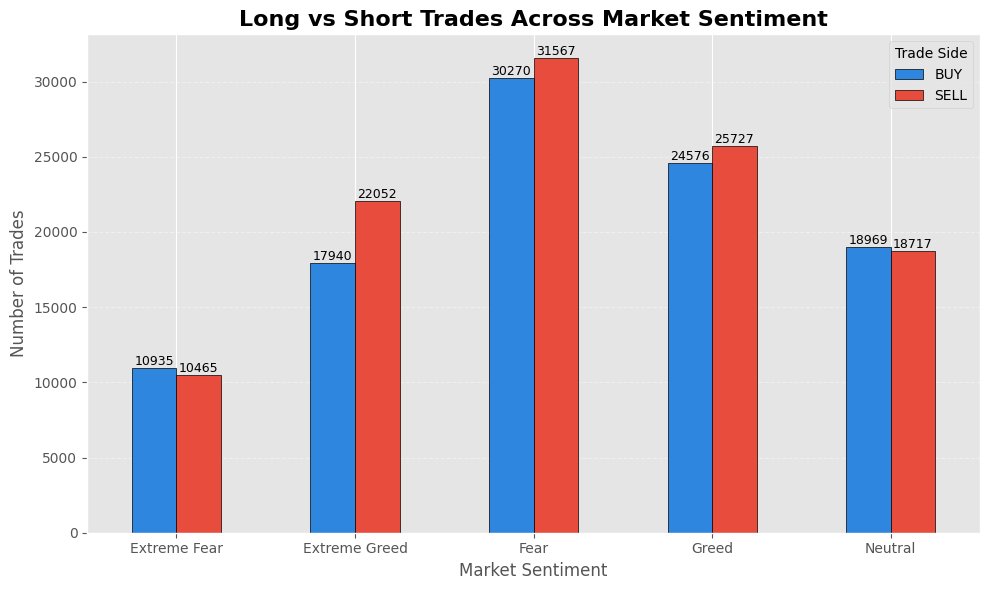

In [70]:
import matplotlib.pyplot as plt

pivot_side = long_short_summary.pivot(
    index="classification",
    columns="Side",
    values="Number_of_Trades"
)

ax = pivot_side.plot(
    kind="bar",
    figsize=(10,6),
    color=["#2E86DE", "#E74C3C"],
    edgecolor="black"
)

plt.title("Long vs Short Trades Across Market Sentiment", fontsize=16, fontweight="bold")
plt.xlabel("Market Sentiment", fontsize=12)
plt.ylabel("Number of Trades", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Trade Side")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

plt.tight_layout()
plt.show()

### Observation

- Buy and Sell trades remained relatively balanced across different market sentiment conditions.
- Extreme Greed showed a slightly higher number of Sell trades.
- Market sentiment influenced trading direction only marginally.

### Profit and Loss Analysis by Market Sentiment

This analysis compares trader profitability across different market sentiment categories to identify whether market emotions influence trading performance.

In [60]:
# ==========================================================
# Average PnL by Market Sentiment
# ==========================================================

pnl_summary = (
    merged_df
    .groupby("classification")
    .agg(
        Average_PnL=("Closed PnL","mean"),
        Total_PnL=("Closed PnL","sum"),
        Total_Trades=("Closed PnL","count")
    )
    .reset_index()
)

pnl_summary

,classification,Average_PnL,Total_PnL,Total_Trades
0,Extreme Fear,34.537862,7.391102e+05,21400
1,Extreme Greed,67.892861,2.715171e+06,39992
2,Fear,54.290400,3.357155e+06,61837
3,Greed,42.743559,2.150129e+06,50303
4,Neutral,34.307718,1.292921e+06,37686


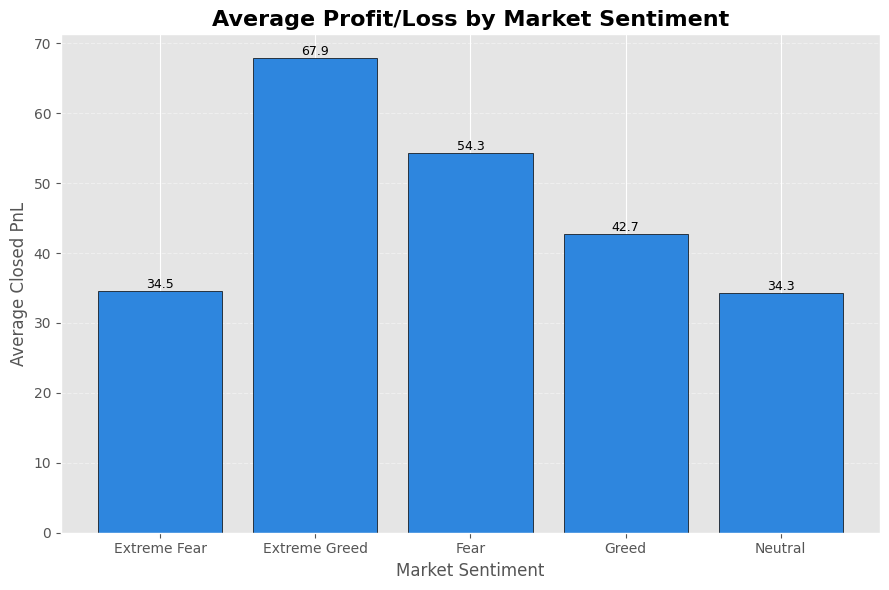

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

bars = plt.bar(
    pnl_summary["classification"],
    pnl_summary["Average_PnL"],
    color="#2E86DE",
    edgecolor="black"
)

plt.title("Average Profit/Loss by Market Sentiment", fontsize=16, fontweight="bold")
plt.xlabel("Market Sentiment", fontsize=12)
plt.ylabel("Average Closed PnL", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Observation

- Extreme Greed recorded the highest average Closed PnL.
- Neutral and Extreme Fear periods showed comparatively lower profitability.
- Trader profitability appears to improve during stronger bullish sentiment.

### Trade Frequency by Market Sentiment

This analysis measures how frequently traders participate in the market under different sentiment conditions.

In [62]:
# ==========================================================
# Trade Frequency by Sentiment
# ==========================================================

trade_frequency = (
    merged_df
    .groupby("classification")
    .agg(
        Total_Trades=("Account", "count"),
        Unique_Traders=("Account", "nunique")
    )
    .reset_index()
)

trade_frequency

,classification,Total_Trades,Unique_Traders
0,Extreme Fear,21400,32
1,Extreme Greed,39992,30
2,Fear,61837,32
3,Greed,50303,31
4,Neutral,37686,31


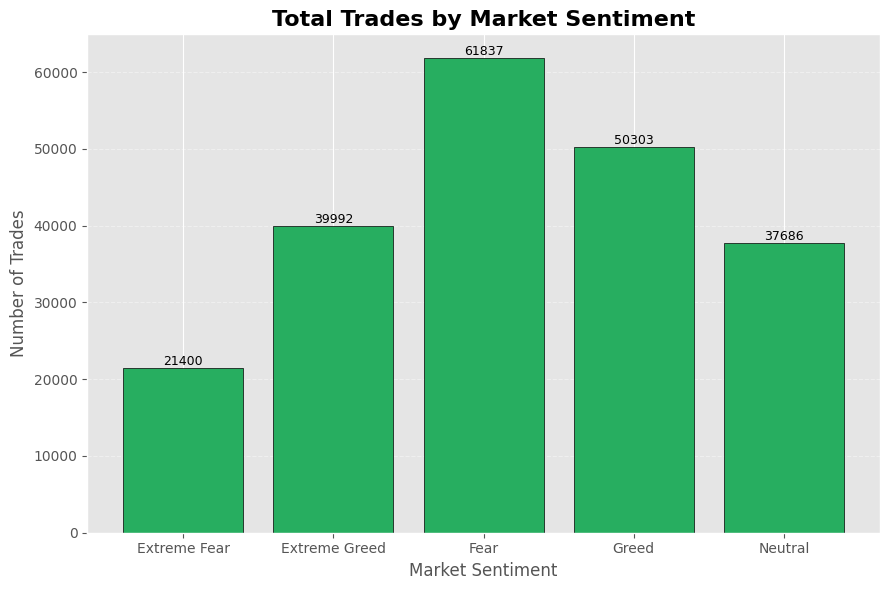

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

bars = plt.bar(
    trade_frequency["classification"],
    trade_frequency["Total_Trades"],
    color="#27AE60",
    edgecolor="black"
)

plt.title("Total Trades by Market Sentiment", fontsize=16, fontweight="bold")
plt.xlabel("Market Sentiment", fontsize=12)
plt.ylabel("Number of Trades", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Observation

- Fear recorded the highest number of total trades (61,837), indicating maximum trading activity.
- Extreme Fear showed the lowest trading volume (21,400), suggesting traders were more cautious.
- Trading activity was generally higher during Fear and Greed market conditions than during Neutral or Extreme Fear.

## 7. Sentiment Analysis

### Overall Sentiment Comparison

This section combines profitability, trade frequency and trader behaviour to compare trading performance across different market sentiment conditions.

In [64]:
# ==========================================================
# Combine Key Sentiment Metrics
# ==========================================================

sentiment_summary = (
    merged_df
    .groupby("classification")
    .agg(
        Average_PnL=("Closed PnL","mean"),
        Total_Trades=("Account","count"),
        Average_Trade_Size=("Size USD","mean"),
        Win_Rate=("Win","mean")
    )
    .reset_index()
)

sentiment_summary["Win_Rate"] = sentiment_summary["Win_Rate"]*100

sentiment_summary

,classification,Average_PnL,Total_Trades,Average_Trade_Size,Win_Rate
0,Extreme Fear,34.537862,21400,5349.731843,37.060748
1,Extreme Greed,67.892861,39992,3112.251565,46.494299
2,Fear,54.290400,61837,7816.109931,42.076750
3,Greed,42.743559,50303,5736.884375,38.482794
4,Neutral,34.307718,37686,4782.732661,39.699093


## 8. Trader Segmentation

### Trader Segmentation

This section groups traders based on their trading activity to identify high, medium and low activity traders.

In [65]:
# ==========================================================
# Trader Segmentation
# ==========================================================

trader_activity = (
    merged_df
    .groupby("Account")
    .agg(
        Total_Trades=("Closed PnL", "count"),
        Total_PnL=("Closed PnL", "sum")
    )
    .reset_index()
)

trader_activity.head()

,Account,Total_Trades,Total_PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05


In [66]:
# Create Trader Segments

trader_activity["Segment"] = pd.qcut(
    trader_activity["Total_Trades"],
    q=3,
    labels=["Low Activity", "Medium Activity", "High Activity"]
)

trader_activity.head()

,Account,Total_Trades,Total_PnL,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,Medium Activity
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,High Activity
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,Medium Activity
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,High Activity
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,Medium Activity


In [67]:
segment_summary = (
    trader_activity
    .groupby("Segment")
    .agg(
        Traders=("Account", "count"),
        Average_PnL=("Total_PnL", "mean"),
        Average_Trades=("Total_Trades", "mean")
    )
    .reset_index()
)

segment_summary

/tmp/ipykernel_640/1633335023.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Segment")


,Segment,Traders,Average_PnL,Average_Trades
0,Low Activity,11,159708.161616,894.090909
1,Medium Activity,10,265813.464157,3585.400000
2,High Activity,11,534730.411281,15048.636364


### Consistent Winners vs Inconsistent Traders

This analysis classifies traders based on their average Closed PnL. Traders with a positive average Closed PnL are considered **Consistent Winners**, while traders with a negative average Closed PnL are classified as **Inconsistent Traders**.

In [73]:
# ==========================================================
# Consistent Winners vs Inconsistent Traders
# ==========================================================

winner_summary = (
    merged_df
    .groupby("Account")
    .agg(
        Total_Trades=("Closed PnL", "count"),
        Average_PnL=("Closed PnL", "mean"),
        Total_PnL=("Closed PnL", "sum")
    )
    .reset_index()
)

winner_summary["Trader_Type"] = np.where(
    winner_summary["Average_PnL"] > 0,
    "Consistent Winner",
    "Inconsistent Trader"
)

winner_summary.head()

,Account,Total_Trades,Average_PnL,Total_PnL,Trader_Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,419.127768,1.600230e+06,Consistent Winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,6.577654,4.788532e+04,Consistent Winner
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-18.492043,-7.043619e+04,Inconsistent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,9.951530,1.324648e+05,Consistent Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,52.071011,1.686580e+05,Consistent Winner


In [74]:
winner_segment = (
    winner_summary
    .groupby("Trader_Type")
    .agg(
        Number_of_Traders=("Account", "count"),
        Average_PnL=("Average_PnL", "mean")
    )
    .reset_index()
)

winner_segment

,Trader_Type,Number_of_Traders,Average_PnL
0,Consistent Winner,29,111.005917
1,Inconsistent Trader,3,-31.070041


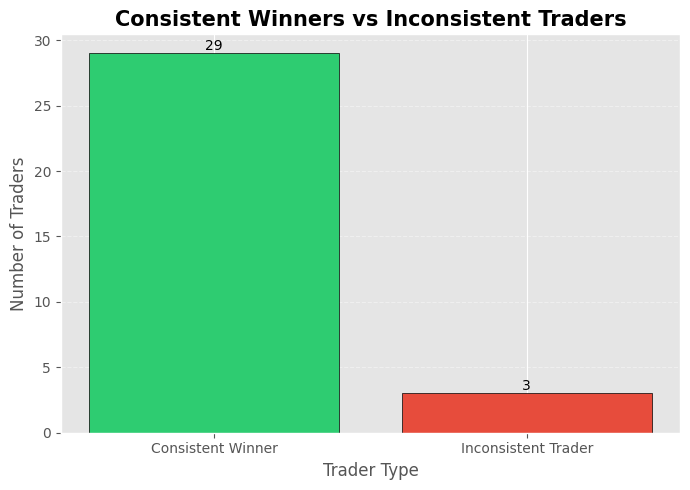

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

bars = plt.bar(
    winner_segment["Trader_Type"],
    winner_segment["Number_of_Traders"],
    color=["#2ECC71", "#E74C3C"],
    edgecolor="black"
)

plt.title(
    "Consistent Winners vs Inconsistent Traders",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Trader Type", fontsize=12)
plt.ylabel("Number of Traders", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Observation

- Consistent Winners maintain a positive average Closed PnL over multiple trades.
- Inconsistent Traders have a negative average Closed PnL, indicating less stable trading performance.
- This segmentation helps identify traders who consistently perform better over time.

## 9. Key Insights

• Fear market sentiment recorded the highest trading activity with 61,837 total trades.

• Extreme Greed showed the highest average profit (67.89), indicating strong profitability during bullish market conditions.

• Extreme Fear generated the lowest average profit (34.54), reflecting higher trading risk.

• High Activity traders achieved significantly higher average profit than Medium and Low Activity traders.

• Buy and Sell trades remained relatively balanced across all market sentiment categories.

• Market sentiment has a clear influence on trading activity and trader profitability.

## 10. Strategy Recommendations

- Increase trading activity during Extreme Greed conditions, as average profitability is highest.
- Apply stronger risk management during Extreme Fear periods to reduce potential losses.
- Monitor trader win rates regularly to identify top-performing traders.
- Focus on improving the performance of Low Activity traders through better trading strategies.
- Use market sentiment as an additional indicator while making trading decisions.
- Continuously track trading performance using dashboards and key performance metrics.

## Future Improvements

- Integrate real-time market data for live analysis.
- Build an interactive dashboard using Power BI or Tableau.
- Apply machine learning models to predict trader profitability.
- Analyze additional technical indicators such as RSI, MACD, and Moving Averages.
- Develop a real-time trader performance monitoring system.
- Deploy the project as a web application using Streamlit.

## Conclusion
This project analyzed trader performance using historical trading data and the Fear & Greed Index.

The analysis included:
- Data Cleaning and Preprocessing
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Sentiment Analysis
- Trader Segmentation
- Key Insights and Strategy Recommendations

The results show that market sentiment has a significant impact on trading activity and profitability. High-activity traders generally achieved better performance, while Extreme Greed conditions produced the highest average profit.

This project demonstrates practical skills in Python, Pandas, Data Analysis, Data Visualization, and Business Insights.

## Dataset Limitations

- The provided dataset does not include a leverage column, so leverage-based analysis could not be performed.
- The analysis is based only on the available historical trading records and Fear & Greed Index data.
- Results should be interpreted within the scope of the provided datasets.